In [3]:
import pandas as pd

df = pd.read_csv("./Position_Salaries.csv")
df.head(5)

,Position,Level,Salary,Years of Experience
0,Intern,0.5,30000,2.9
1,Trainee,1.0,35000,5.7
2,Business Analyst,1.5,45000,8.5
3,Junior Consultant,2.0,50000,12.7
4,Consultant,2.5,55000,17.6


In [4]:
X = df.loc[:, ["Level"]]
y = df["Salary"]

In [5]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

X_scaler = StandardScaler()
y_scaler = StandardScaler()

X_transformed = X_scaler.fit_transform(X)
X_transformed = pd.DataFrame(X_transformed, columns=["Level"])

y_transformed = y_scaler.fit_transform(y.values.reshape(-1, 1))
y_transformed = pd.Series(y_transformed.ravel())

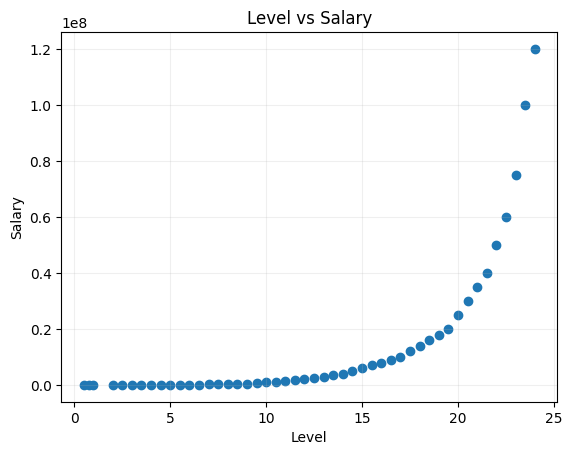

In [287]:
import matplotlib.pyplot as plt

plt.scatter(X, y)
plt.xlabel("Level")
plt.ylabel("Salary")
plt.grid(True, alpha=0.2)
plt.title("Level vs Salary")
plt.show()

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_transformed, y_transformed, random_state=1997, test_size=0.2)

In [7]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
pd.Series(y_pred).head()

0   -1.010644
1    1.033109
2    0.456666
3    0.037435
4    0.404262
dtype: float64

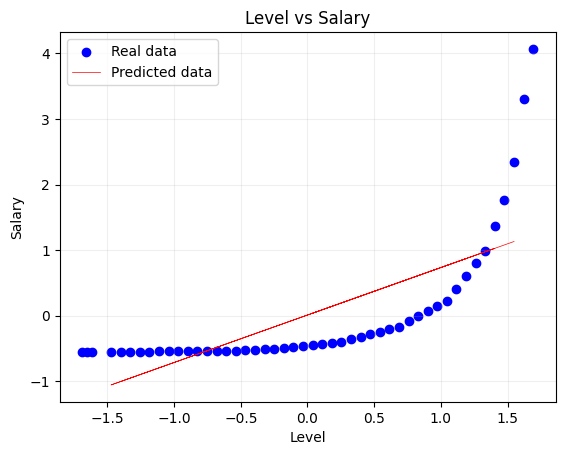

In [290]:
import matplotlib.pyplot as plt

plt.scatter(X_transformed, y_transformed, color="blue", label="Real data")
plt.xlabel("Level")
plt.ylabel("Salary")
plt.grid(True, alpha=0.2)
plt.title("Level vs Salary")
plt.plot(X_test, y_pred, color="red", linestyle="-", label="Predicted data", linewidth=0.5)
plt.legend()
plt.show()

In [8]:
residuals = y_test - y_pred
residuals

4     0.464548
43    0.341568
32   -0.658758
24   -0.485656
31   -0.644811
40   -0.270376
3     0.516759
22   -0.411614
27   -0.589027
45    1.198205
dtype: float64

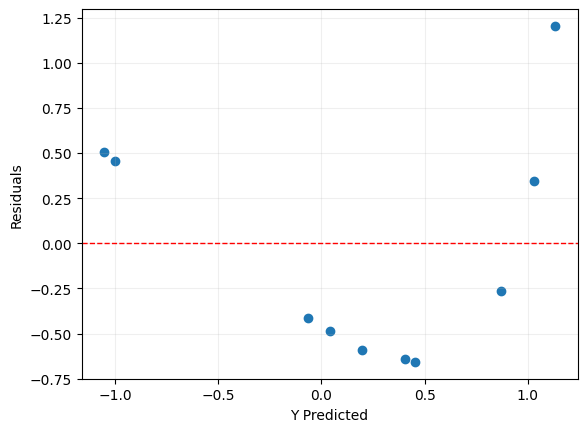

In [292]:
import matplotlib.pyplot as plt

plt.scatter(x=y_pred, y=residuals)
plt.axhline(0, linestyle="--", color="red", linewidth=1)
plt.grid(True, alpha=0.2)
plt.xlabel("Y Predicted")
plt.ylabel("Residuals")
plt.show()

In [9]:
from sklearn.svm import SVR

reg = SVR(kernel='rbf', epsilon=0.1)
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)
y_pred

array([-0.49139228,  1.23807148, -0.28757763, -0.42857751, -0.34064497,
        0.72338829, -0.48561122, -0.42235935, -0.42962647,  1.53173398])

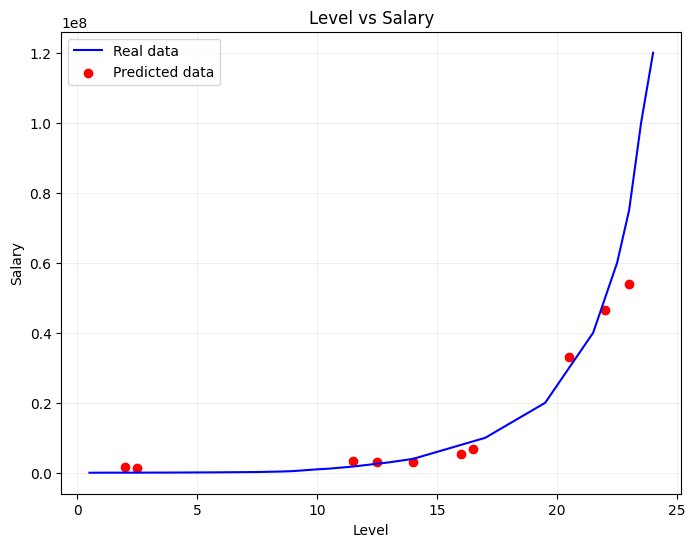

In [312]:
import matplotlib.pyplot as plt

X_real = X_scaler.inverse_transform(X_transformed)
y_real = y_scaler.inverse_transform(y_transformed.to_numpy().reshape(-1, 1))

# Desescalar X_test y y_pred
X_test_original = X_scaler.inverse_transform(X_test)
y_pred_original = y_scaler.inverse_transform(y_pred.reshape(-1, 1))

# Graficar datos reales
plt.figure(figsize=(8, 6))
plt.plot(X_real, y_real, color="blue", label="Real data")

# Graficar predicción ordenada
plt.scatter(X_test_original, y_pred_original, color="red", label="Predicted data")

# Configuración del gráfico
plt.xlabel("Level")
plt.ylabel("Salary")
plt.grid(True, alpha=0.2)
plt.title("Level vs Salary")
plt.legend()
plt.show()

In [313]:
residuals = y_test - y_pred 
residuals

4    -0.053936
43    0.138812
32    0.083974
24   -0.018706
31    0.099148
40   -0.118559
3    -0.060066
22   -0.056117
27    0.036082
45    0.808224
dtype: float64

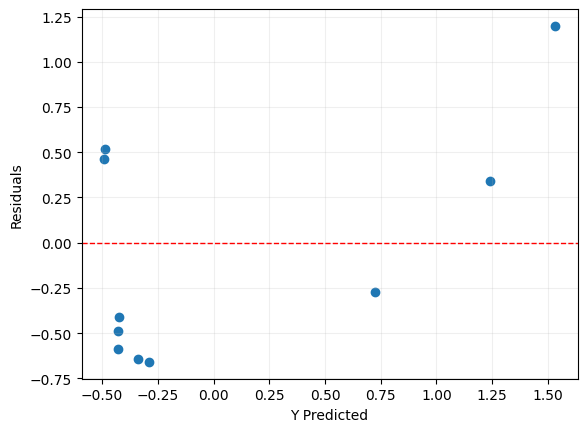

In [10]:
import matplotlib.pyplot as plt

plt.scatter(x=y_pred, y=residuals)
plt.axhline(0, linestyle="--", color="red", linewidth=1)
plt.grid(True, alpha=0.2)
plt.xlabel("Y Predicted")
plt.ylabel("Residuals")
plt.show()

In [300]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"MAE (degree=7): {mae}")
print(f"MSE (degree=7): {mse}")

MAE (degree=7): 0.14736234231637774
MSE (degree=7): 0.07147508894485724


In [11]:
import statsmodels.api as sm

reg_OLS = sm.OLS(y, X_poly).fit()
reg_OLS.summary()

NameError: name 'X_poly' is not defined